# UMAP KNN Cell-to-Cell Nearest Neighbors

Runs supervised UMAP + KNN for **EXC** and **INH** cells and records the **3 nearest
patchseq neighbors** (cell IDs and UMAP distances) for each minnie cell — no label
aggregation.

Columns produced per minnie cell:

| Column | Description |
|--------|-------------|
| `id` | minnie cell ID |
| `nn_1_id` | nearest patchseq cell ID |
| `nn_1_dist` | UMAP distance to nn_1 |
| `nn_2_id` | 2nd nearest patchseq cell ID |
| `nn_2_dist` | UMAP distance to nn_2 |
| `nn_3_id` | 3rd nearest patchseq cell ID |
| `nn_3_dist` | UMAP distance to nn_3 |

Results are saved to h5ad with the `_cellToCell` suffix.

In [9]:
import sys
import os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

%load_ext autoreload
%autoreload 2

from umap_label_transfer import UMAPLabelTransfer
import anndata as ad
import pandas as pd

DATA_ROOT = '/scratch/combined_datasets'
H5AD_OUT  = '/scratch/h5ad_outputs'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## EXC — supervised UMAP + cell-to-cell nearest neighbors

Patchseq features: (389, 53)
Unique patchseq cells: 384, unique labels: 17 (deepest label only)
Patchseq after label join: (384, 56)
Minnie features: (49714, 58)
Shared features:  48
Only in patchseq: 4  → ['axon_exit_theta', 'heirachy_category', 'axon_exit_distance', 'level']
Only in minnie:   7  → ['basal_dendrite_depth_pc_2', 'soma_surface_area', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_1']
Patchseq: 384 → 384 rows (dropped 0)
Minnie:   49714 → 49714 rows (dropped 0)
Scaled patchseq (robust): (384, 48)
Scaled minnie   (robust): (49714, 48)
Patchseq embedding (supervised): (384, 2)
Minnie embedding   (supervised): (49714, 2)
Nearest neighbors computed: 49714 minnie cells × 3 neighbors


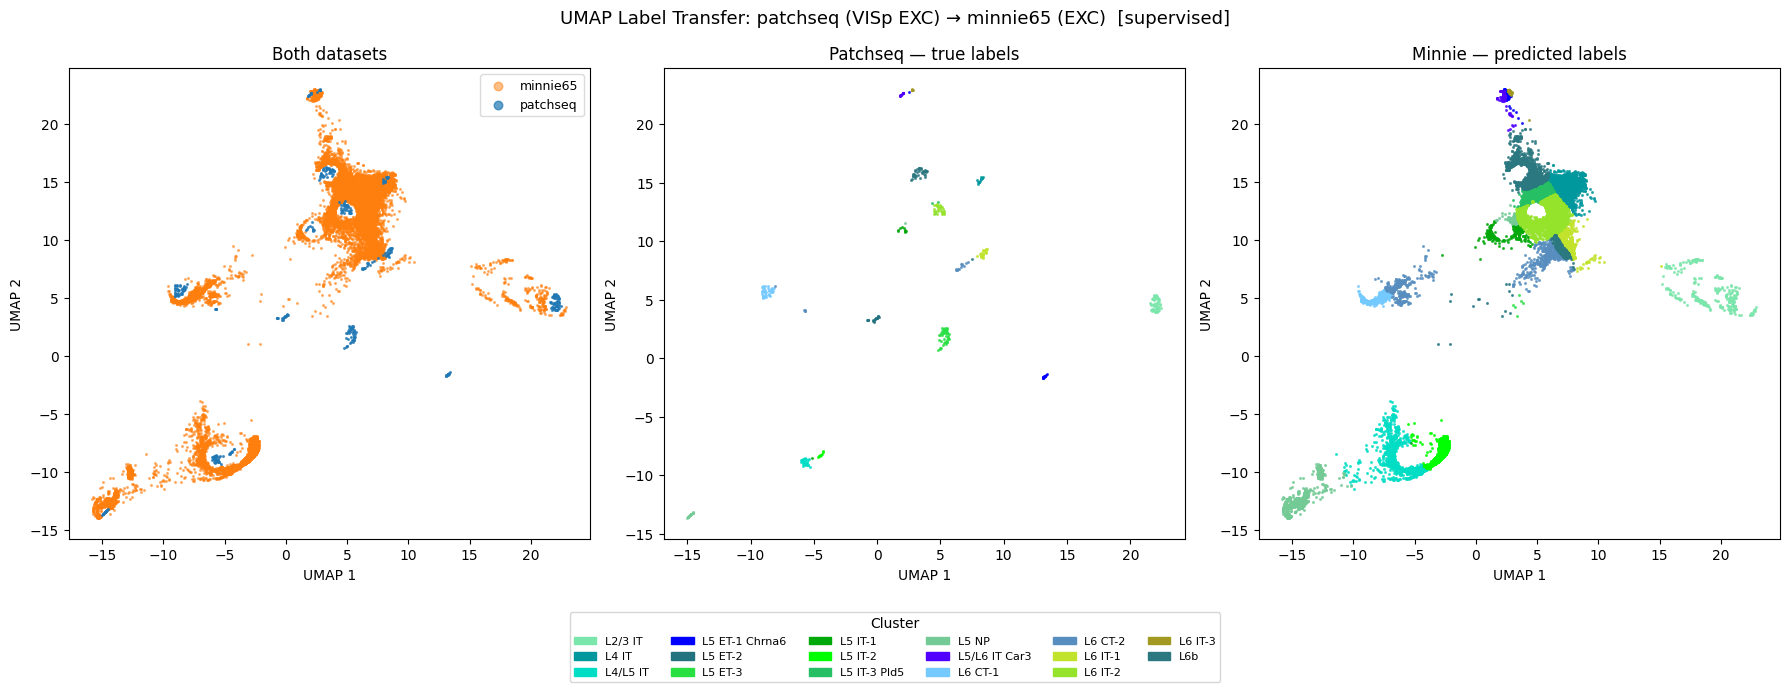

In [10]:
lt_exc = UMAPLabelTransfer(DATA_ROOT, cell_type='exc')
lt_exc.load_data()
lt_exc.harmonize_features()
lt_exc.scale(method='robust')
lt_exc.fit_umap(mode='supervised')
lt_exc.find_nearest_neighbors(k=3)
lt_exc.plot_umap()

In [11]:
print('EXC nearest_neighbors shape:', lt_exc.nearest_neighbors.shape)
lt_exc.nearest_neighbors.head(10)

EXC nearest_neighbors shape: (49714, 10)


,id,nn_1_id,nn_1_label,nn_1_dist,nn_2_id,nn_2_label,nn_2_dist,nn_3_id,nn_3_label,nn_3_dist
0,23141,610440978,L6b,0.941725,1010692386,L6b,1.070908,984034203,L6b,1.190587
1,23332,965535967,L6 IT-1,0.690688,983928133,L6b,0.690846,794963377,L6 IT-1,0.804676
2,23373,893401406,L5 IT-2,1.537057,850968263,L5 IT-2,1.543387,645834123,L5 IT-2,1.554805
3,23382,965535967,L6 IT-1,0.677635,794963377,L6 IT-1,0.719848,896619350,L6 IT-1,0.771412
4,23385,906532711,L5 IT-2,1.447108,971586225,L5 IT-2,1.453609,645834123,L5 IT-2,1.456139
5,23388,841882659,L6 IT-2,0.974119,922742835,L6 IT-2,0.990799,990548306,L6 IT-2,1.004849
6,23389,948126701,L4 IT,0.560272,642777215,L4 IT,0.699873,639910703,L4 IT,0.721679
7,23398,680973517,L4 IT,0.616621,639910703,L4 IT,0.676102,948126701,L4 IT,0.743750
8,23413,893401406,L5 IT-2,1.649966,850968263,L5 IT-2,1.651719,645834123,L5 IT-2,1.734112
9,23550,948126701,L4 IT,0.510586,642777215,L4 IT,0.650086,643798256,L4 IT,0.672877


In [12]:
exc_path = os.path.join(H5AD_OUT, 'exc_minnie_met_umapknn_cellToCell.h5ad')
lt_exc.save_cell_to_cell_h5ad(exc_path)

Saved cell-to-cell h5ad → /scratch/h5ad_outputs/exc_minnie_met_umapknn_cellToCell.h5ad  (49714 cells)


## INH — supervised UMAP + cell-to-cell nearest neighbors

Patchseq features: (520, 49)
Unique patchseq cells: 495, unique labels: 28 (deepest label only)
Patchseq after label join: (495, 52)
Minnie features: (163, 54)
Shared features:  46
Only in patchseq: 2  → ['heirachy_category', 'level']
Only in minnie:   5  → ['basal_dendrite_depth_pc_2', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_3']
Patchseq: 495 → 495 rows (dropped 0)
Minnie:   163 → 163 rows (dropped 0)
Scaled patchseq (robust): (495, 46)
Scaled minnie   (robust): (163, 46)
Patchseq embedding (supervised): (495, 2)
Minnie embedding   (supervised): (163, 2)
Nearest neighbors computed: 163 minnie cells × 3 neighbors


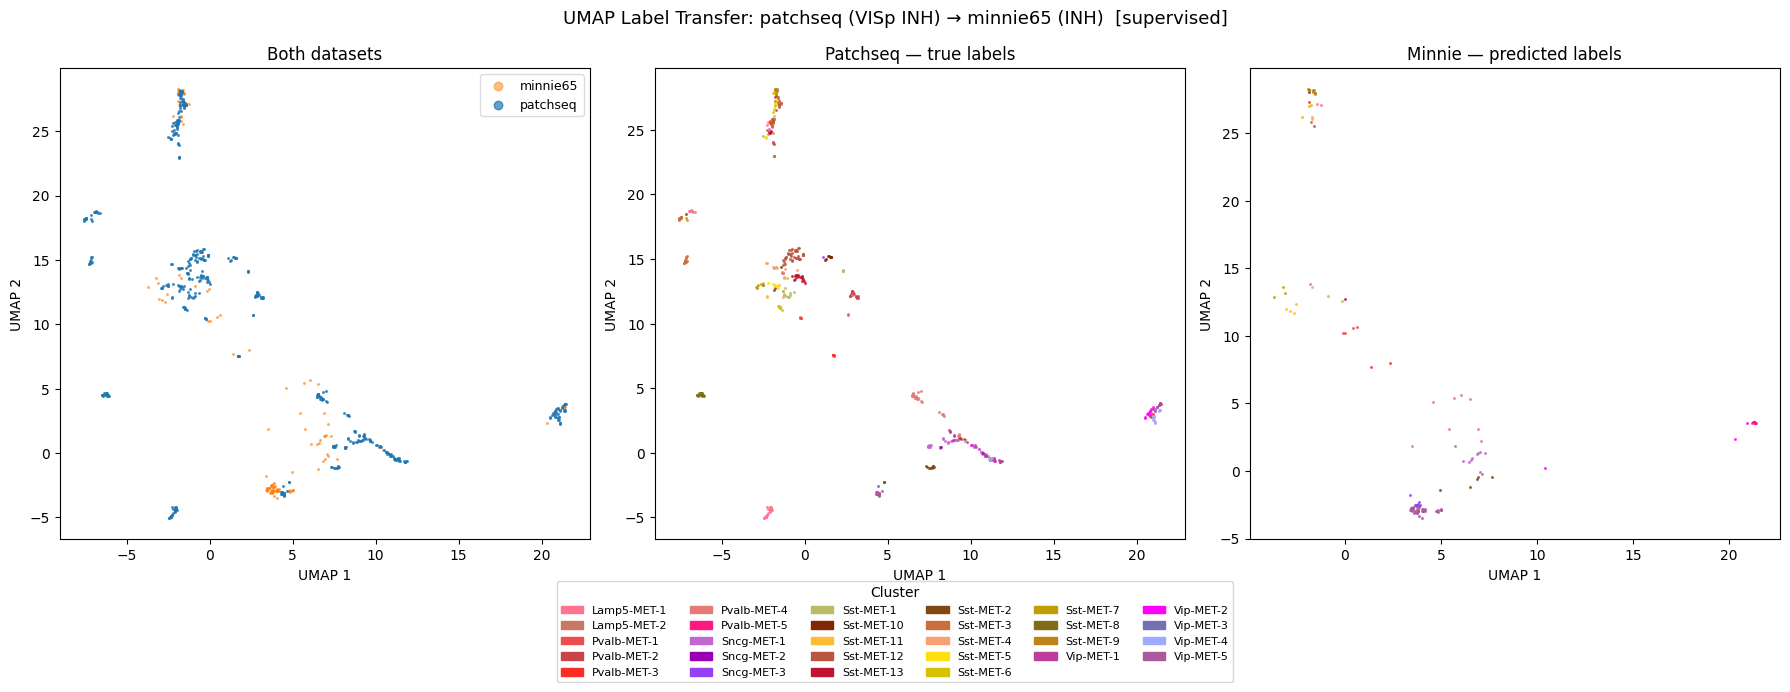

In [13]:
lt_inh = UMAPLabelTransfer(DATA_ROOT, cell_type='inh')
lt_inh.load_data()
lt_inh.harmonize_features()
lt_inh.scale(method='robust')
lt_inh.fit_umap(mode='supervised')
lt_inh.find_nearest_neighbors(k=3)
lt_inh.plot_umap()

In [14]:
print('INH nearest_neighbors shape:', lt_inh.nearest_neighbors.shape)
lt_inh.nearest_neighbors.head(10)

INH nearest_neighbors shape: (163, 10)


,id,nn_1_id,nn_1_label,nn_1_dist,nn_2_id,nn_2_label,nn_2_dist,nn_3_id,nn_3_label,nn_3_dist
0,252232,669165397,Sst-MET-9,0.117921,766591236,Sst-MET-9,0.119863,759939473,Sst-MET-9,0.154354
1,255120,743504177,Vip-MET-5,0.383290,743468218,Vip-MET-5,0.583962,761822060,Vip-MET-5,0.613410
2,255129,745584401,Sst-MET-11,0.545047,750776506,Sst-MET-11,0.597643,657442490,Sst-MET-7,1.097547
3,255137,759751429,Vip-MET-5,0.849474,644920227,Vip-MET-5,0.864767,692777680,Vip-MET-5,0.880134
4,255208,759751429,Vip-MET-5,0.650425,644920227,Vip-MET-5,0.652239,692777680,Vip-MET-5,0.676127
5,255218,669165397,Sst-MET-9,0.117743,766591236,Sst-MET-9,0.119669,759939473,Sst-MET-9,0.154149
6,256424,644920227,Vip-MET-5,0.638989,759751429,Vip-MET-5,0.643343,692777680,Vip-MET-5,0.667335
7,256426,606308411,Pvalb-MET-5,0.061309,639004612,Vip-MET-1,0.086172,700413526,Vip-MET-3,0.117908
8,256446,759751429,Vip-MET-5,0.597528,992830261,Sncg-MET-3,0.598850,692777680,Vip-MET-5,0.651175
9,256514,759751429,Vip-MET-5,0.799590,692777680,Vip-MET-5,0.841256,694183636,Vip-MET-5,0.853391


In [15]:
inh_path = os.path.join(H5AD_OUT, 'inh_minnie_met_umapknn_cellToCell.h5ad')
lt_inh.save_cell_to_cell_h5ad(inh_path)

Saved cell-to-cell h5ad → /scratch/h5ad_outputs/inh_minnie_met_umapknn_cellToCell.h5ad  (163 cells)


## Read back and verify

In [17]:
for label, path in [('EXC', exc_path), ('INH', inh_path)]:
    adata = ad.read_h5ad(path)
    print(f'--- {label} ({adata.n_obs} cells) ---')
    display(adata.obs.head(5))
    print()

--- EXC (49714 cells) ---


,id,nn_1_id,nn_1_label,nn_1_dist,nn_2_id,nn_2_label,nn_2_dist,nn_3_id,nn_3_label,nn_3_dist
0,23141,610440978,L6b,0.941725,1010692386,L6b,1.070908,984034203,L6b,1.190587
1,23332,965535967,L6 IT-1,0.690688,983928133,L6b,0.690846,794963377,L6 IT-1,0.804676
2,23373,893401406,L5 IT-2,1.537057,850968263,L5 IT-2,1.543387,645834123,L5 IT-2,1.554805
3,23382,965535967,L6 IT-1,0.677635,794963377,L6 IT-1,0.719848,896619350,L6 IT-1,0.771412
4,23385,906532711,L5 IT-2,1.447108,971586225,L5 IT-2,1.453609,645834123,L5 IT-2,1.456139



--- INH (163 cells) ---


,id,nn_1_id,nn_1_label,nn_1_dist,nn_2_id,nn_2_label,nn_2_dist,nn_3_id,nn_3_label,nn_3_dist
0,252232,669165397,Sst-MET-9,0.117921,766591236,Sst-MET-9,0.119863,759939473,Sst-MET-9,0.154354
1,255120,743504177,Vip-MET-5,0.383290,743468218,Vip-MET-5,0.583962,761822060,Vip-MET-5,0.613410
2,255129,745584401,Sst-MET-11,0.545047,750776506,Sst-MET-11,0.597643,657442490,Sst-MET-7,1.097547
3,255137,759751429,Vip-MET-5,0.849474,644920227,Vip-MET-5,0.864767,692777680,Vip-MET-5,0.880134
4,255208,759751429,Vip-MET-5,0.650425,644920227,Vip-MET-5,0.652239,692777680,Vip-MET-5,0.676127
